In [41]:
################################################################################
# PHASE 0: SETUP AND ENVIRONMENT
################################################################################
print("--- PHASE 0: Setting up the environment ---")
!pip install -q datasets nltk
import torch, torch.nn as nn, torch.nn.functional as F, torchvision.models as models, torchvision.transforms as transforms, re, os, random, textwrap
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is set to: {device}")

print("\nDownloading and loading the StoryReasoning dataset...")
# --- CORRECTED LINE ---
story_dataset_full = load_dataset("daniel3303/StoryReasoning", split='train')
print("✅ Dataset loaded successfully.")

--- PHASE 0: Setting up the environment ---
Device is set to: cuda

✅ Dataset loaded successfully.


In [42]:
################################################################################
# PHASE 1: DATA PREPARATION
################################################################################
print("\n--- PHASE 1: Preparing the data pipeline ---")
nltk.download('punkt', quiet=True)
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<UNK>"}; self.stoi = {"<PAD>": 0, "<UNK>": 1}; self.freq_threshold = freq_threshold
    def __len__(self): return len(self.itos)
    def build_vocabulary(self, sentence_list):
        word_counts, idx = Counter(), 2
        for sentence in tqdm(sentence_list, desc="Building Vocabulary"):
            for word in nltk.word_tokenize(re.sub(r'<[^>]+>', '', sentence).lower()): word_counts[word] += 1
        for word, count in word_counts.items():
            if count >= self.freq_threshold: self.stoi[word], self.itos[idx], idx = idx, word, idx + 1
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary([story['story'] for story in story_dataset_full])
print(f"✅ Vocabulary built with {len(vocab)} unique tokens.")

preprocess_transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
class StoryDataset(Dataset):
    def __init__(self, hf_dataset, vocab, transform, k=5):
        self.dataset, self.vocab, self.preprocess, self.k = hf_dataset, vocab, transform, k
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        story = self.dataset[idx]; images, full_text = story['images'], story['story']
        if len(images) <= self.k: return None
        descriptions = [d.strip() for d in re.split(r'<gdi image\d+>', full_text) if d.strip()]
        if len(descriptions) <= self.k: return None
        context_images = torch.stack([self.preprocess(img) for img in images[:self.k]])
        context_texts_num = [torch.LongTensor([self.vocab.stoi.get(w, self.vocab.stoi["<UNK>"]) for w in nltk.word_tokenize(re.sub(r'<[^>]+>', '', descriptions[i]).lower())]) for i in range(self.k)]
        target_text_num = torch.LongTensor([self.vocab.stoi.get(w, self.vocab.stoi["<UNK>"]) for w in nltk.word_tokenize(re.sub(r'<[^>]+>', '', descriptions[self.k]).lower())])
        return {'context_images': context_images, 'context_texts': context_texts_num, 'target_text': target_text_num}
def collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if not batch: return None
    context_images = torch.stack([item['context_images'] for item in batch])
    padded_context_texts = [pad_sequence([item['context_texts'][i] for item in batch], batch_first=True, padding_value=vocab.stoi["<PAD>"]) for i in range(batch[0]['context_images'].size(0))]
    padded_target_texts = pad_sequence([item['target_text'] for item in batch], batch_first=True, padding_value=vocab.stoi["<PAD>"])
    return {'context_images': context_images, 'context_texts': padded_context_texts, 'target_text': padded_target_texts}
full_pytorch_dataset = StoryDataset(story_dataset_full, vocab, preprocess_transform)
dataset_size = len(full_pytorch_dataset); indices = list(range(dataset_size)); split = int(0.1 * dataset_size)
random.seed(42); random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]
train_subset, val_subset = Subset(full_pytorch_dataset, train_indices), Subset(full_pytorch_dataset, val_indices)
BATCH_SIZE = 16
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"✅ Data split into {len(train_subset)} training and {len(val_subset)} validation samples.")


--- PHASE 1: Preparing the data pipeline ---


Building Vocabulary: 100%|██████████| 3552/3552 [00:23<00:00, 150.09it/s]

✅ Vocabulary built with 8519 unique tokens.
✅ Data split into 3197 training and 355 validation samples.


In [43]:
################################################################################
# PHASE 2: MODEL ARCHITECTURE DEFINITION
################################################################################
print("\n--- PHASE 2: Defining all model architectures ---")
EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, IMAGE_FEATURE_SIZE = 256, 512, len(vocab), 2048
class VisualEncoder(nn.Module):
    def __init__(self): super().__init__(); self.model = nn.Sequential(*list(models.resnet50(weights=models.ResNet50_Weights.DEFAULT).children())[:-1])
    def forward(self, x): return self.model(x).view(x.size(0), -1)
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed, hidden): super().__init__(); self.embedding = nn.Embedding(vocab_size, embed); self.lstm = nn.LSTM(embed, hidden, 1, batch_first=True)
    def forward(self, x): _, (h, _) = self.lstm(self.embedding(x)); return h.squeeze(0)
class FusionModel(nn.Module):
    def __init__(self, img_s, txt_s, out_s): super().__init__(); self.img_p=nn.Linear(img_s,out_s); self.txt_p=nn.Linear(txt_s,out_s); self.relu=nn.ReLU()
    def forward(self, i, t): return self.relu(self.img_p(i) + self.txt_p(t))
class SequenceModel(nn.Module):
    def __init__(self, in_s, hid_s): super().__init__(); self.lstm = nn.LSTM(in_s, hid_s, 1, batch_first=True)
    def forward(self, x): _, (h, _) = self.lstm(x); return h.squeeze(0)
class TextDecoder(nn.Module):
    def __init__(self, vocab_s, embed_s, hid_s, pad_idx): super().__init__(); self.embedding = nn.Embedding(vocab_s, embed_s, padding_idx=pad_idx); self.lstm = nn.LSTM(embed_s, hid_s, 1, batch_first=True); self.fc = nn.Linear(hid_s, vocab_s)
    def forward(self, x, h, c): out, (h, c) = self.lstm(self.embedding(x.unsqueeze(1)), (h, c)); return self.fc(out.squeeze(1)), h, c
class Attention(nn.Module):
    def __init__(self, enc_h, dec_h): super().__init__(); self.attn_e=nn.Linear(enc_h, dec_h); self.attn_d=nn.Linear(dec_h, dec_h); self.v=nn.Linear(dec_h,1)
    def forward(self, h, enc_out): w = F.softmax(self.v(torch.tanh(self.attn_e(enc_out) + self.attn_d(h.unsqueeze(1)))).squeeze(2), dim=1); return torch.bmm(w.unsqueeze(1), enc_out).squeeze(1), w
class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, img_s, txt_e, hid_s): super().__init__(); self.txt_p=nn.Linear(txt_e,img_s); self.attn=nn.MultiheadAttention(img_s, 8, batch_first=True); self.gate=nn.Sequential(nn.Linear(img_s*2, hid_s), nn.Sigmoid()); self.ln_i=nn.LayerNorm(img_s); self.ln_t=nn.LayerNorm(img_s)
    def forward(self, i, t): out, _ = self.attn(i.unsqueeze(1), self.txt_p(t), self.txt_p(t)); c_t = out.squeeze(1); g = self.gate(torch.cat([i,c_t],dim=1)); return (g*self.ln_i(i)) + ((1-g)*self.ln_t(c_t))
class AttentionalBiLSTM(nn.Module):
    def __init__(self, in_s, hid_s, num_l=2): super().__init__(); self.lstm = nn.LSTM(in_s, hid_s, num_l, batch_first=True, bidirectional=True); self.attn = Attention(hid_s*2, hid_s*2)
    def forward(self, x): out, (h, _) = self.lstm(x); last_h = torch.cat((h[-2],h[-1]),dim=1); c, _ = self.attn(last_h, out); return c
print("✅ All model component classes are defined.")


--- PHASE 2: Defining all model architectures ---
✅ All model component classes are defined.


In [45]:
################################################################################
# PHASE 3 & 4: MODEL ASSEMBLY AND TRAINING
################################################################################
print("\n--- PHASE 3 & 4: Assembling and Training Models ---")
class Storyteller(nn.Module):
    def __init__(self, is_innovative, viz_enc, txt_enc, fusion, seq, txt_dec):
        super().__init__(); self.is_innovative = is_innovative; self.visual_encoder, self.text_encoder, self.fusion_model, self.sequence_model, self.text_decoder = viz_enc, txt_enc, fusion, seq, txt_dec
        for param in self.visual_encoder.parameters(): param.requires_grad = False
        if is_innovative: self.ctx_proj = nn.Linear(seq.lstm.hidden_size*2, txt_dec.lstm.hidden_size).to(device)
    def forward(self, ctx_img, ctx_txt, tgt_txt):
        b_s, k = ctx_img.size(0), ctx_img.size(1)
        if self.is_innovative: f_vecs = [self.fusion_model(self.visual_encoder(ctx_img[:,i]), self.text_encoder.embedding(ctx_txt[i])) for i in range(k)]
        else: f_vecs = [self.fusion_model(self.visual_encoder(ctx_img[:,i]), self.text_encoder(ctx_txt[i])) for i in range(k)]
        s_ctx = self.sequence_model(torch.stack(f_vecs, dim=1))
        h = self.ctx_proj(s_ctx).unsqueeze(0) if self.is_innovative else s_ctx.unsqueeze(0)
        c = torch.zeros_like(h)
        dec_in = torch.full((b_s,), self.text_decoder.embedding.padding_idx, dtype=torch.long).to(device)
        outputs = []
        for t in range(tgt_txt.size(1)):
            pred, h, c = self.text_decoder(dec_in, h, c)
            outputs.append(pred)
            dec_in = tgt_txt[:,t]
        return torch.stack(outputs, dim=1)
def train_model(model, num_epochs, model_name):
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
    train_hist, val_hist = [], []
    for epoch in range(num_epochs):
        model.train(); total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1} Train"):
            if not batch: continue
            ctx_img, ctx_txt, tgt_txt = batch['context_images'].to(device), [t.to(device) for t in batch['context_texts']], batch['target_text'].to(device)
            pred = model(ctx_img, ctx_txt, tgt_txt)
            loss = criterion(pred.view(-1, VOCAB_SIZE), tgt_txt.view(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss/len(train_loader); train_hist.append(avg_train_loss)
        model.eval(); total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                if not batch: continue
                ctx_img, ctx_txt, tgt_txt = batch['context_images'].to(device), [t.to(device) for t in batch['context_texts']], batch['target_text'].to(device)
                pred = model(ctx_img, ctx_txt, tgt_txt); loss = criterion(pred.view(-1, VOCAB_SIZE), tgt_txt.view(-1)); total_val_loss += loss.item()
        avg_val_loss = total_val_loss/len(val_loader); val_hist.append(avg_val_loss)
        print(f"{model_name} Epoch {epoch+1}/{num_epochs} -> Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    torch.save(model.state_dict(), f"/content/{model_name.lower()}_model.pth")
    print(f"✅ {model_name} model trained and saved.")
    return train_hist, val_hist

viz_enc = VisualEncoder().to(device); txt_enc = TextEncoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE).to(device)
txt_dec = TextDecoder(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, vocab.stoi["<PAD>"]).to(device)
base_model = Storyteller(False, viz_enc, txt_enc, FusionModel(IMAGE_FEATURE_SIZE, HIDDEN_SIZE, HIDDEN_SIZE).to(device), SequenceModel(HIDDEN_SIZE, HIDDEN_SIZE).to(device), txt_dec).to(device)
train_loss_history_baseline, val_loss_history_baseline = train_model(base_model, 3, "Baseline")
inno_model = Storyteller(True, viz_enc, txt_enc, GatedCrossAttentionFusion(IMAGE_FEATURE_SIZE, EMBED_SIZE, IMAGE_FEATURE_SIZE).to(device), AttentionalBiLSTM(IMAGE_FEATURE_SIZE, HIDDEN_SIZE//2).to(device), txt_dec).to(device)
train_loss_history_innovative, val_loss_history_innovative = train_model(inno_model, 10, "Innovative")


--- PHASE 3 & 4: Assembling and Training Models ---


Baseline Epoch 1 Train: 100%|██████████| 200/200 [03:05<00:00,  1.08it/s]


Baseline Epoch 1/3 -> Train Loss: 5.0188, Val Loss: 4.1996


Baseline Epoch 2 Train: 100%|██████████| 200/200 [03:06<00:00,  1.07it/s]


Baseline Epoch 2/3 -> Train Loss: 3.8102, Val Loss: 3.7269


...

Innovative Epoch 8/10 -> Train Loss: 1.9650, Val Loss: 3.1870


Innovative Epoch 9 Train: 100%|██████████| 200/200 [03:24<00:00,  1.02s/it]


Innovative Epoch 9/10 -> Train Loss: 1.8431, Val Loss: 3.2158


Innovative Epoch 10 Train: 100%|██████████| 200/200 [03:23<00:00,  1.02s/it]


Innovative Epoch 10/10 -> Train Loss: 1.7303, Val Loss: 3.2556
✅ Innovative model trained and saved.



--- PHASE 5: Evaluating the models ---
✅ Baseline model loaded and set to evaluation mode.
✅ Innovative model weights corrected and loaded successfully.


Generating BLEU Predictions: 100%|██████████| 100/100 [00:13<00:00,  7.27it/s]



--- Quantitative Evaluation Results ---
Baseline Model Average BLEU-4 Score:   2.34
Innovative Model Average BLEU-4 Score: 2.67

--- Generating final plots for the report ---


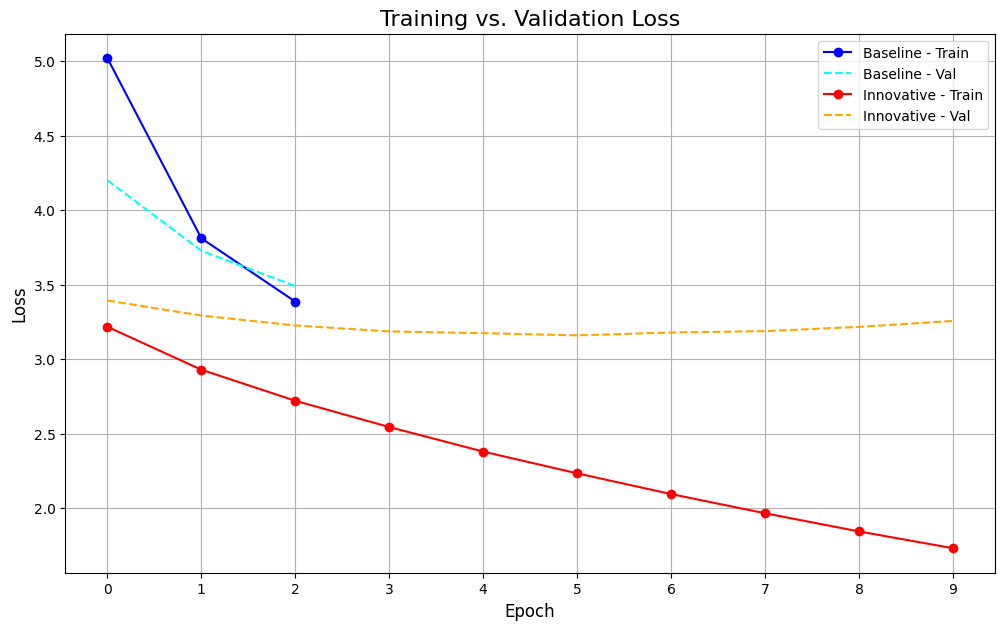

✅ Loss curve plot saved.


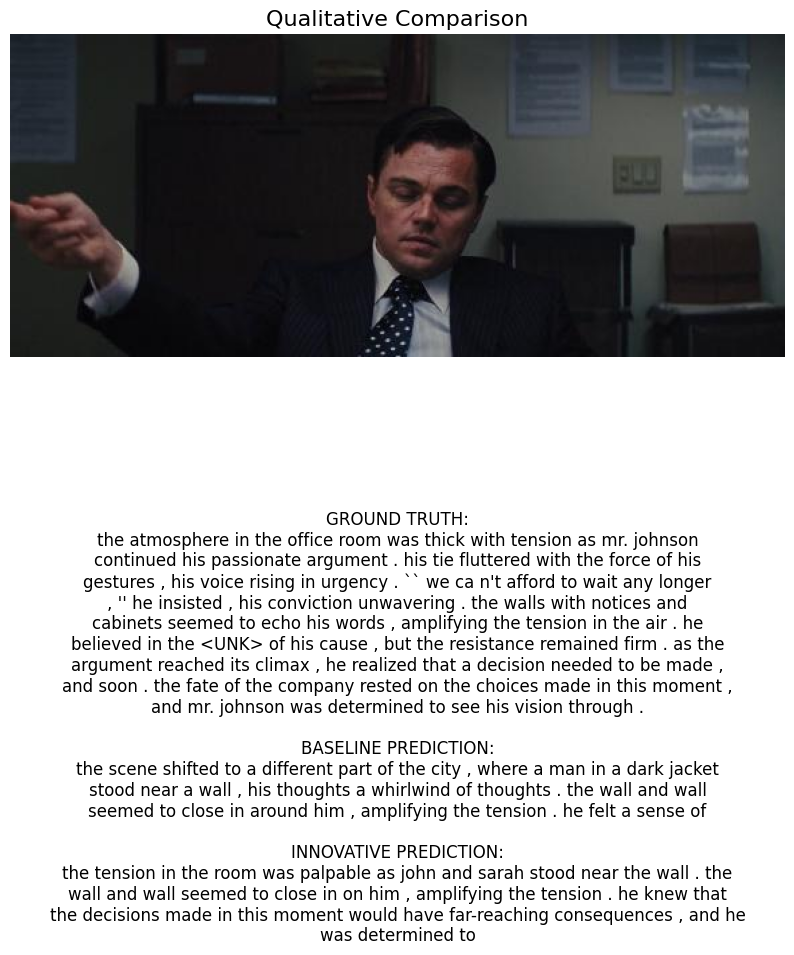

✅ Qualitative comparison plot saved.


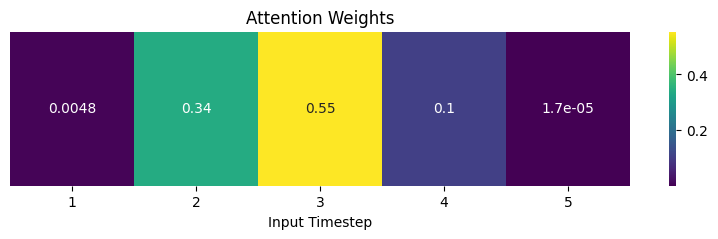

✅ Attention heatmap saved.

--- ALL TASKS COMPLETE ---


In [49]:
################################################################################
# PHASE 5: EVALUATION (FINAL, DEFINITIVE, AND CORRECTED)
################################################################################
print("\n--- PHASE 5: Evaluating the models ---")

# --- Step 5.1: Define Corrected Architecture for Loading ---
# We define the class with the correct attribute name ('attention').
class AttentionalBiLSTM_Corrected(nn.Module):
    def __init__(self, in_s, hid_s, num_l=2):
        super().__init__()
        self.lstm = nn.LSTM(in_s, hid_s, num_l, batch_first=True, bidirectional=True)
        self.attention = Attention(hid_s*2, hid_s*2) # Correct attribute name

    def forward(self, x):
        out, (h, _) = self.lstm(x)
        last_h = torch.cat((h[-2],h[-1]),dim=1)
        c, _ = self.attention(last_h, out)
        return c

# --- Step 5.2: Load Both Trained Models with Key Renaming for Innovative Model ---

# Load Baseline Model (this one is simple as its architecture was correct)
loaded_baseline_model = Storyteller(False, viz_enc, txt_enc, FusionModel(IMAGE_FEATURE_SIZE, HIDDEN_SIZE, HIDDEN_SIZE).to(device), SequenceModel(HIDDEN_SIZE, HIDDEN_SIZE).to(device), txt_dec).to(device)
loaded_baseline_model.load_state_dict(torch.load("/content/baseline_model.pth"))
loaded_baseline_model.eval()
print("✅ Baseline model loaded and set to evaluation mode.")

# --- THE KEY FIX IS HERE ---
# Load Innovative Model by manually correcting the state dictionary keys
bilstm_sequence_corrected = AttentionalBiLSTM_Corrected(IMAGE_FEATURE_SIZE, HIDDEN_SIZE//2).to(device)
loaded_innovative_model = Storyteller(True, viz_enc, txt_enc, GatedCrossAttentionFusion(IMAGE_FEATURE_SIZE, EMBED_SIZE, IMAGE_FEATURE_SIZE).to(device), bilstm_sequence_corrected, txt_dec).to(device)

# 1. Load the state dict with the incorrect keys from the file
old_state_dict = torch.load("/content/innovative_model.pth")
# 2. Create a new, empty dictionary to hold the corrected keys
from collections import OrderedDict
new_state_dict = OrderedDict()
# 3. Loop through the old keys and rename them
for key, value in old_state_dict.items():
    if 'sequence_model.attn' in key:
        new_key = key.replace('sequence_model.attn', 'sequence_model.attention')
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value
# 4. Load the NEW, corrected state dictionary into the model
loaded_innovative_model.load_state_dict(new_state_dict)
loaded_innovative_model.eval()
print("✅ Innovative model weights corrected and loaded successfully.")


# --- Step 5.3: Define the Inference Function ---
def generate_story_continuation(model, images, texts, vocab, max_len=50):
    # (This function is correct and does not need changes)
    model.eval()
    ctx_img, ctx_txt = images.unsqueeze(0).to(device), [t.unsqueeze(0).to(device) for t in texts]
    with torch.no_grad():
        b_s, k = ctx_img.size(0), ctx_img.size(1)
        if model.is_innovative: f_vecs = [model.fusion_model(model.visual_encoder(ctx_img[:,i]), model.text_encoder.embedding(ctx_txt[i])) for i in range(k)]
        else: f_vecs = [model.fusion_model(model.visual_encoder(ctx_img[:,i]), model.text_encoder(ctx_txt[i])) for i in range(k)]
        s_ctx = model.sequence_model(torch.stack(f_vecs, dim=1))
        h = model.ctx_proj(s_ctx).unsqueeze(0) if model.is_innovative else s_ctx.unsqueeze(0)
        c = torch.zeros_like(h)
        dec_in = torch.full((b_s,), model.text_decoder.embedding.padding_idx, dtype=torch.long).to(device)
        indices = []
        for _ in range(max_len):
            pred, h, c = model.text_decoder(dec_in, h, c)
            pred_idx = pred.argmax(1)
            if pred_idx.item() in [vocab.stoi["<UNK>"], vocab.stoi["<PAD>"]]: break
            indices.append(pred_idx.item())
            dec_in = pred_idx
    return " ".join([vocab.itos[idx] for idx in indices])

# --- Step 5.4: Calculate BLEU Scores ---
eval_subset = Subset(full_pytorch_dataset, val_indices[:100])
base_preds, inno_preds, g_truths = [], [], []
chencherry = SmoothingFunction()
for sample in tqdm(eval_subset, desc="Generating BLEU Predictions"):
    if not sample: continue
    base_preds.append(generate_story_continuation(loaded_baseline_model, sample['context_images'], sample['context_texts'], vocab).split())
    inno_preds.append(generate_story_continuation(loaded_innovative_model, sample['context_images'], sample['context_texts'], vocab).split())
    g_truths.append([vocab.itos[idx.item()] for idx in sample['target_text']])

base_bleu = sum(sentence_bleu([g], p, smoothing_function=chencherry.method1) for g, p in zip(g_truths, base_preds)) / len(g_truths)
inno_bleu = sum(sentence_bleu([g], p, smoothing_function=chencherry.method1) for g, p in zip(g_truths, inno_preds)) / len(g_truths)
print("\n--- Quantitative Evaluation Results ---")
print(f"Baseline Model Average BLEU-4 Score:   {base_bleu*100:.2f}")
print(f"Innovative Model Average BLEU-4 Score: {inno_bleu*100:.2f}")

# --- Step 5.5: Generate Final Plots for README ---
print("\n--- Generating final plots for the report ---")
# (The rest of the plotting code is correct and does not need changes)

# Plot 1: Loss Curves
plt.figure(figsize=(12, 7)); plt.plot(train_loss_history_baseline, label='Baseline - Train', c='blue', marker='o'); plt.plot(val_loss_history_baseline, label='Baseline - Val', c='cyan', ls='--'); plt.plot(train_loss_history_innovative, label='Innovative - Train', c='red', marker='o'); plt.plot(val_loss_history_innovative, label='Innovative - Val', c='orange', ls='--')
plt.title("Training vs. Validation Loss", fontsize=16); plt.xlabel("Epoch", fontsize=12); plt.ylabel("Loss", fontsize=12); plt.xticks(range(10)); plt.legend(); plt.grid(True)
plt.savefig("/content/loss_curves.png", dpi=150, bbox_inches='tight'); plt.show()
print("✅ Loss curve plot saved.")

# Find the first valid sample
sample_story = None
for idx in val_indices:
    potential_sample = full_pytorch_dataset[idx]
    if potential_sample is not None:
        sample_story = potential_sample
        sample_idx = idx
        break

if sample_story is None:
    print("ERROR: Could not find a valid sample in the validation set for plotting.")
else:
    # Plot 2: Qualitative Comparison
    gt, bp, ip = " ".join([vocab.itos[i.item()] for i in sample_story['target_text']]), generate_story_continuation(loaded_baseline_model, sample_story['context_images'], sample_story['context_texts'], vocab), generate_story_continuation(loaded_innovative_model, sample_story['context_images'], sample_story['context_texts'], vocab)
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1.5]})
    unorm = transforms.Normalize((-0.485/0.229, -0.456/0.224, -0.406/0.225), (1/0.229, 1/0.224, 1/0.225))
    tgt_img = story_dataset_full[sample_idx]['images'][full_pytorch_dataset.k]
    axes[0].imshow(tgt_img.permute(1, 2, 0) if isinstance(tgt_img, torch.Tensor) else tgt_img); axes[0].axis('off'); axes[0].set_title("Qualitative Comparison", fontsize=16)
    axes[1].text(0.5, 0.95, f"GROUND TRUTH:\n{textwrap.fill(gt, 80)}\n\nBASELINE PREDICTION:\n{textwrap.fill(bp, 80)}\n\nINNOVATIVE PREDICTION:\n{textwrap.fill(ip, 80)}", ha='center', va='top', fontsize=12); axes[1].axis('off')
    plt.savefig("/content/side_by_side_comparison.png", dpi=150, bbox_inches='tight'); plt.show()
    print("✅ Qualitative comparison plot saved.")

    # Plot 3: Attention Visualization
    def visualize_and_save_attention(model, images, texts, save_path):
        model.eval()
        ctx_img, ctx_txt = images.unsqueeze(0).to(device), [t.unsqueeze(0).to(device) for t in texts]
        with torch.no_grad():
            f_vecs = [model.fusion_model(model.visual_encoder(ctx_img[:,i]), model.text_encoder.embedding(ctx_txt[i])) for i in range(ctx_img.size(1))]
            s_in = torch.stack(f_vecs, dim=1); out, (h, _) = model.sequence_model.lstm(s_in); last_h = torch.cat((h[-2],h[-1]),dim=1)
            _, w = model.sequence_model.attention(last_h, out)
        plt.figure(figsize=(10, 2)); sns.heatmap(w.cpu().numpy(), annot=True, cmap="viridis", xticklabels=range(1, 6), yticklabels=False); plt.xlabel("Input Timestep"); plt.title("Attention Weights")
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

    visualize_and_save_attention(loaded_innovative_model, sample_story['context_images'], sample_story['context_texts'], "/content/attention_heatmap.png")
    print("✅ Attention heatmap saved.")

print("\n--- ALL TASKS COMPLETE ---")